<a href="https://colab.research.google.com/github/irfkirf/Norm-dtsc-3601-project/blob/main/Untitled2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd

# Load your cleaned dataset
df = pd.read_csv("cleaned_property_crimes.csv")   # use the cleaned version you saved earlier

# Quick check
print(df.shape)
df.head()


(408821, 15)


,DATE OCC,Month,DayOfWeek,Hour,AREA,AREA NAME,Crm Cd,Crm Cd Desc,Vict Age,Vict Age Group,Vict Sex,Vict Descent,Premis Desc,LAT,LON
0,2020-11-07,11,Saturday,8,15,N Hollywood,354,THEFT OF IDENTITY,31,31-50,M,H,SINGLE FAMILY DWELLING,34.2124,-118.4092
1,2020-10-30,10,Friday,12,9,Van Nuys,354,THEFT OF IDENTITY,30,18-30,M,W,SINGLE FAMILY DWELLING,34.1847,-118.4509
2,2020-12-24,12,Thursday,13,7,Wilshire,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,47,31-50,F,A,STREET,34.0339,-118.3747
3,2020-09-29,9,Tuesday,18,14,Pacific,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),63,51+,M,H,ALLEY,33.9813,-118.4350
4,2020-11-11,11,Wednesday,12,4,Hollenbeck,354,THEFT OF IDENTITY,35,31-50,M,B,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",34.0830,-118.1678


In [12]:
print(df.columns)


Index(['DATE OCC', 'Month', 'DayOfWeek', 'Hour', 'AREA', 'AREA NAME', 'Crm Cd',
       'Crm Cd Desc', 'Vict Age', 'Vict Age Group', 'Vict Sex', 'Vict Descent',
       'Premis Desc', 'LAT', 'LON'],
      dtype='object')


In [13]:
# Create the target column
df['crime_group'] = df['Crm Cd Desc'].apply(
    lambda x: 'Theft' if 'THEFT' in x.upper() else 
              ('Break-in' if 'BURGLARY' in x.upper() or 'BREAKING' in x.upper() else 'Other')
)


In [14]:
df = df[df['crime_group'].isin(['Theft', 'Break-in'])]


In [15]:
X = df.drop(columns=['crime_group'])
y = df['crime_group']


In [16]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Target = Theft vs Break-in
X = df.drop(columns=['crime_group'])  # predictors
y = df['crime_group']                 # labels

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Baseline model (majority class)
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

# Predictions
y_pred = baseline.predict(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred)
print("Baseline Accuracy:", acc)
print(classification_report(y_test, y_pred))



Baseline Accuracy: 0.6905399620864673


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

    Break-in       0.00      0.00      0.00     25303
       Theft       0.69      1.00      0.82     56462

    accuracy                           0.69     81765
   macro avg       0.35      0.50      0.41     81765
weighted avg       0.48      0.69      0.56     81765



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


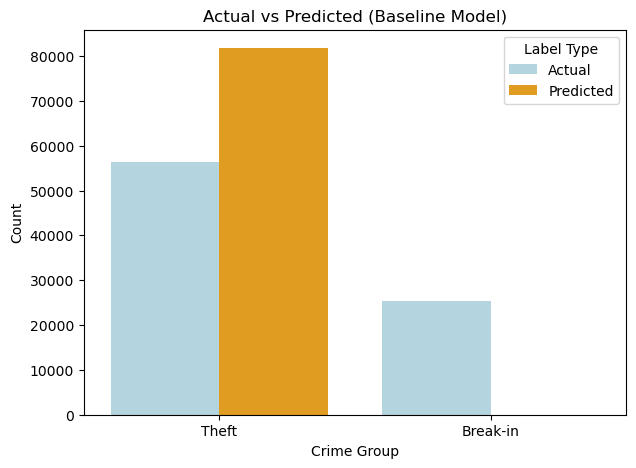

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Combine actual and predicted values into one DataFrame
comparison_df = pd.DataFrame({
    'Label Type': ['Actual'] * len(y_test) + ['Predicted'] * len(y_pred),
    'Crime Group': list(y_test) + list(y_pred)
})

plt.figure(figsize=(7,5))
sns.countplot(data=comparison_df, x='Crime Group', hue='Label Type', palette=['lightblue', 'orange'])
plt.title("Actual vs Predicted (Baseline Model)")
plt.xlabel("Crime Group")
plt.ylabel("Count")
plt.legend(title="Label Type")
plt.show()



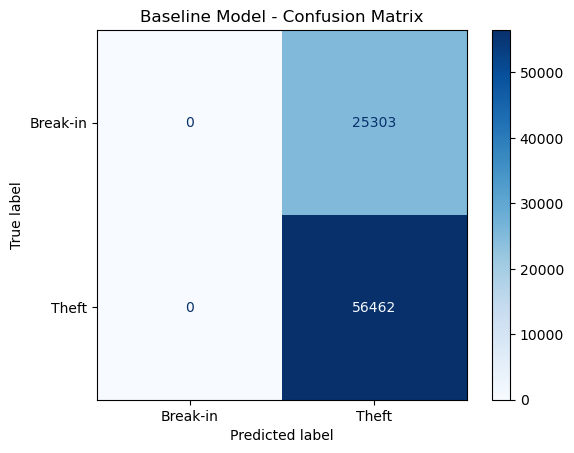

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(baseline, X_test, y_test, cmap="Blues")
plt.title("Baseline Model - Confusion Matrix")
plt.show()
